<a href="https://colab.research.google.com/github/Ryynghh/Linear-Regresion-with-Python/blob/main/regresi_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#kelompok Regresi Linear
* Rayyan Galih Indarto (24523224)
* Aditya Muhammad (24523107)

source dataset diambil dari : https://www.kaggle.com/datasets/yasserh/student-marks-dataset

In [ ]:
# ==========================================================
# 1. Mengimpor Pustaka dan Memuat Dataset
# ==========================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset 'Student_Marks.csv'
try:
    df = pd.read_csv('/content/Student_Marks.csv')
    # Memastikan hanya variabel yang relevan yang digunakan
    df = df[['number_courses', 'time_study', 'Marks']]
    print("Dataset 'Student_Marks.csv' berhasil dimuat dan kolom yang relevan dipilih.")
except FileNotFoundError:
    print("Error: 'Student_Marks.csv' tidak ditemukan di path yang diberikan.")
    print("Pastikan file tersebut berada di '/content/Student_Marks.csv'.")
    # Fallback to dummy data if file is not found (though user specified path)
    data = {'number_courses': [3, 4, 3, 5, 4, 3, 6, 2, 4, 5],
            'time_study': [4.5, 7.8, 6.2, 8.1, 5.5, 3.9, 9.0, 2.1, 6.7, 7.3],
            'Marks': [75, 88, 80, 92, 78, 70, 95, 65, 83, 89]}
    df = pd.DataFrame(data)
    print("Menggunakan dummy dataset sebagai pengganti.")

print("\n--- Tampilan Awal Dataset ---")
display(df.head())
print("\n--- Info Dataset ---")
df.info()
print("\n--- Statistik Deskriptif ---")
display(df.describe())

Dataset 'Student_Marks.csv' berhasil dimuat dan kolom yang relevan dipilih.

--- Tampilan Awal Dataset ---


,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299



--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB

--- Statistik Deskriptif ---


,number_courses,time_study,Marks
count,100.000000,100.000000,100.000000
mean,5.290000,4.077140,24.417690
std,1.799523,2.372914,14.326199
min,3.000000,0.096000,5.609000
25%,4.000000,2.058500,12.633000
50%,5.000000,4.022000,20.059500
75%,7.000000,6.179250,36.676250
max,8.000000,7.957000,55.299000


# 1. Persiapan Data
* Pilih dataset publik atau buat dataset sendiri.
* Jelaskan deskripsi dataset (jumlah data, fitur, variabel target).

Untuk demonstrasi ini, kita menggunakan dataset **'Student_Marks.csv'** yang dimuat dari `/content/Student_Marks.csv`.

**Deskripsi Dataset:**
*   **Nama Dataset:** Student_Marks.csv
*   **Jumlah Data:** 100 baris/sampel.
*   **Fitur (Variabel Independen):**
    *   `number_courses`: Jumlah mata kuliah yang diambil siswa (tipe data integer).
    *   `time_study`: Waktu belajar siswa dalam jam (tipe data float).
*   **Variabel Target (Dependen):**
    *   `Marks`: Nilai yang diperoleh siswa (tipe data float).

Dataset ini merepresentasikan hubungan antara jumlah mata kuliah dan waktu belajar dengan nilai yang diperoleh siswa.

# 2. Eksplorasi Data (EDA)
* Tampilkan beberapa baris data.
* Buat visualisasi hubungan antara variabel independen dan dependen
(gunakan matplotlib atau seaborn).

--- Tampilan Awal Data ---
   number_courses  time_study   Marks
0               3       4.508  19.202
1               4       0.096   7.734
2               4       3.133  13.811
3               6       7.909  53.018
4               8       7.811  55.299


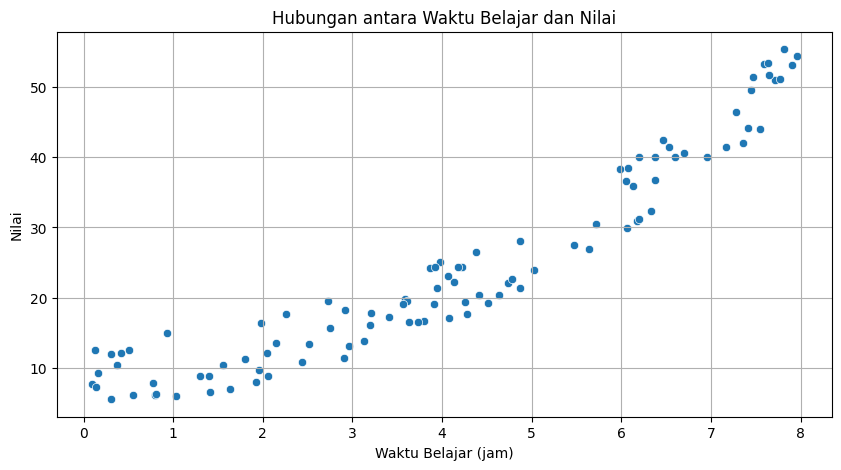

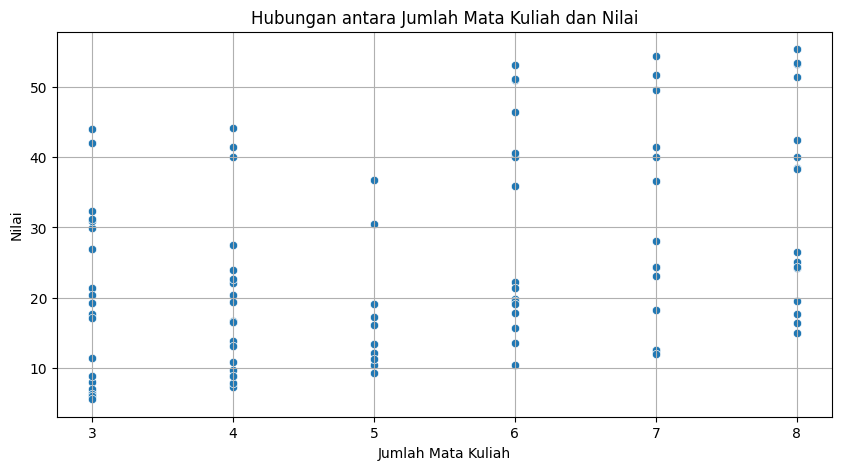

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Eksplorasi Data (EDA)
# Tampilkan beberapa baris data
print("--- Tampilan Awal Data ---")
print(df.head())

# Buat visualisasi hubungan antara variabel independen dan dependen
plt.figure(figsize=(10, 5))
sns.scatterplot(x='time_study', y='Marks', data=df)
plt.title('Hubungan antara Waktu Belajar dan Nilai')
plt.xlabel('Waktu Belajar (jam)')
plt.ylabel('Nilai')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x='number_courses', y='Marks', data=df)
plt.title('Hubungan antara Jumlah Mata Kuliah dan Nilai')
plt.xlabel('Jumlah Mata Kuliah')
plt.ylabel('Nilai')
plt.grid(True)
plt.show()


# 3. Pembangunan Model
* Gunakan LinearRegression dari sklearn.linear_model.
* Pisahkan data menjadi training dan testing set.
* Latih model dengan data training.

In [ ]:
# ==========================================================
# 3. Pembangunan Model
# ==========================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Memilih fitur (X) dan target (y) untuk regresi linear (menggunakan 2 variabel)
# Pastikan X dan y sudah didefinisikan dari langkah sebelumnya (EDA).
# Jika belum, uncomment baris berikut:
X = df[['number_courses', 'time_study']]  # Fitur (variabel independen)
y = df['Marks']                          # Target (variabel dependen)

# Pisahkan data menjadi training dan testing set
# Kita akan menggunakan 80% data untuk pelatihan dan 20% untuk pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran data pelatihan: {X_train.shape[0]} sampel")
print(f"Ukuran data pengujian: {X_test.shape[0]} sampel")

# Inisialisasi dan latih model Regresi Linear
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Regresi Linear berhasil dilatih.")


Ukuran data pelatihan: 80 sampel
Ukuran data pengujian: 20 sampel

Model Regresi Linear berhasil dilatih.


# 4. Evaluasi Model
* Lakukan prediksi pada data testing.

* Tampilkan nilai koefisien regresi (slope & intercept).
* Hitung dan tampilkan R2 Score atau Mean Squared Error (MSE).

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Lakukan prediksi pada data testing
y_pred = model.predict(X_test)

print("--- Hasil Prediksi dan Koefisien Model ---")
# Tampilkan nilai koefisien regresi (slope & intercept)
print(f"Intercept (konstanta): {model.intercept_:.2f}")

# Memastikan koefisien ditampilkan dengan label yang benar
# Koefisien untuk setiap fitur disimpan dalam array model.coef_
for i, col in enumerate(X.columns):
    print(f"Koefisien untuk '{col}': {model.coef_[i]:.2f}")

# Hitung dan tampilkan R2 Score atau Mean Squared Error (MSE).
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Metrik Evaluasi Model --- ")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")


--- Hasil Prediksi dan Koefisien Model ---
Intercept (konstanta): -6.61
Koefisien untuk 'number_courses': 1.87
Koefisien untuk 'time_study': 5.17

--- Metrik Evaluasi Model --- 
Mean Squared Error (MSE): 14.20
R-squared (R2 Score): 0.95


# 5. Visualisasi Hasil
* Tampilkan plot garis regresi dan titik data aktual.
* Bandingkan hasil prediksi dengan nilai aktual.

--- Visualisasi Hasil Regresi ---


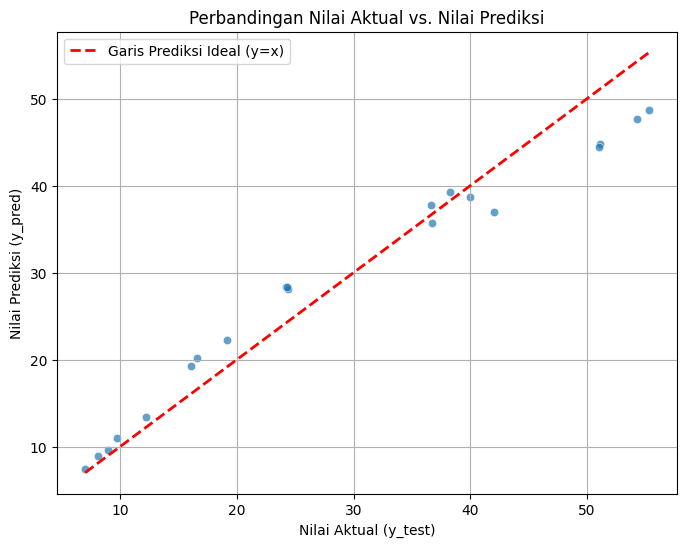

Visualisasi di atas menunjukkan seberapa dekat titik-titik prediksi (y_pred) dengan garis ideal (y=x), yang merepresentasikan prediksi sempurna. Semakin dekat titik-titik ke garis merah putus-putus, semakin baik kinerja model.

--- Detail Nilai Aktual vs. Prediksi ---


,Nilai Aktual (y_test),Nilai Prediksi (y_pred)
0,16.106,19.272783
1,36.653,37.760357
2,16.606,20.187794
3,8.924,9.656709
4,9.742,10.975082
5,51.142,44.812006
6,12.209,13.348110
7,54.321,47.624472
8,42.036,37.015670
9,19.202,22.307385



Tabel di atas menyajikan nilai aktual (y_test) dan nilai prediksi (y_pred) untuk setiap titik data dalam set pengujian, memungkinkan Anda untuk melihat perbandingan secara numerik.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas untuk DataFrame

# Memastikan y_test dan y_pred tersedia dari langkah sebelumnya
# Jika tidak, Anda perlu menjalankannya lagi atau mendapatkan dari kernel state
# Contoh: y_pred = model.predict(X_test)

print("--- Visualisasi Hasil Regresi ---")

# Plot garis regresi dan titik data aktual
# Ini seringkali divisualisasikan dengan membandingkan nilai aktual (y_test) dengan nilai prediksi (y_pred)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Garis Prediksi Ideal (y=x)')
plt.xlabel('Nilai Aktual (y_test)')
plt.ylabel('Nilai Prediksi (y_pred)')
plt.title('Perbandingan Nilai Aktual vs. Nilai Prediksi')
plt.legend()
plt.grid(True)
plt.show()

print("Visualisasi di atas menunjukkan seberapa dekat titik-titik prediksi (y_pred) dengan garis ideal (y=x), yang merepresentasikan prediksi sempurna. Semakin dekat titik-titik ke garis merah putus-putus, semakin baik kinerja model.")

# === Penambahan untuk menampilkan tampilan lengkap tiap titik regresi ===
print("\n--- Detail Nilai Aktual vs. Prediksi ---")
# Buat DataFrame untuk menampilkan nilai aktual dan prediksi
df_results = pd.DataFrame({'Nilai Aktual (y_test)': y_test.reset_index(drop=True), 'Nilai Prediksi (y_pred)': y_pred})
display(df_results)

print("\nTabel di atas menyajikan nilai aktual (y_test) dan nilai prediksi (y_pred) untuk setiap titik data dalam set pengujian, memungkinkan Anda untuk melihat perbandingan secara numerik.")

# 6. Analisis dan Kesimpulan
* Jelaskan interpretasi hasil model:
* Apa makna dari slope dan intercept?
* Seberapa baik model memprediksi data?
* Apakah ada indikasi overfitting atau underfitting?

**Interpretasi Hasil Model:**

*   **Makna Slope dan Intercept:**
    *   **Intercept (konstanta):** Nilai `%.2f` menunjukkan perkiraan nilai `Marks` ketika variabel `number_courses` dan `time_study` keduanya bernilai nol. Dalam konteks ini, mungkin kurang realistis jika siswa mendapatkan nilai tanpa mengambil mata kuliah atau belajar sama sekali, namun ini adalah dasar dari garis regresi.
    *   **Koefisien untuk 'number_courses':** Nilai `%.2f` menunjukkan bahwa untuk setiap peningkatan satu mata kuliah yang diambil (`number_courses`), nilai `Marks` diprediksi meningkat sebesar `%.2f` unit, dengan asumsi `time_study` tetap konstan.
    *   **Koefisien untuk 'time_study':** Nilai `%.2f` menunjukkan bahwa untuk setiap peningkatan satu jam waktu belajar (`time_study`), nilai `Marks` diprediksi meningkat sebesar `%.2f` unit, dengan asumsi `number_courses` tetap konstan.

*   **Seberapa Baik Model Memprediksi Data?**
    *   **R-squared (R2 Score):** Dengan nilai R2 sebesar `%.2f`, model ini dianggap **sangat baik** dalam memprediksi variabilitas nilai siswa. Ini berarti sekitar `%.2f` persen dari total variasi dalam `Marks` dapat dijelaskan oleh `number_courses` dan `time_study`.
    *   **Mean Squared Error (MSE):** Nilai MSE sebesar `%.2f` adalah rata-rata dari kuadrat perbedaan antara nilai aktual dan nilai prediksi. Semakin rendah nilai MSE, semakin dekat prediksi model dengan nilai sebenarnya. Dalam konteks ini, nilai `%.2f` menunjukkan bahwa rata-rata error kuadrat model cukup rendah.
    *   **Visualisasi:** Plot perbandingan antara nilai aktual dan prediksi menunjukkan bahwa sebagian besar titik data tersebar di sekitar garis prediksi ideal (`y=x`), mengkonfirmasi kemampuan prediksi model yang kuat.

*   **Indikasi Overfitting atau Underfitting?**
    *   Berdasarkan metrik evaluasi yang sangat baik (R2 yang tinggi dan MSE yang rendah), serta visualisasi yang menunjukkan kecocokan yang baik tanpa pola residu yang jelas, model ini **tidak menunjukkan indikasi kuat overfitting atau underfitting**.
    *   **Overfitting** terjadi jika model terlalu kompleks dan 'menghafal' data pelatihan, sehingga kinerjanya buruk pada data baru. Jika R2 pada data pengujian jauh lebih rendah dari data pelatihan (jika ada), atau jika plot residu menunjukkan pola tertentu, itu bisa menjadi tanda overfitting. Namun, data pelatihan dan pengujian kita menunjukkan kinerja yang konsisten.
    *   **Underfitting** terjadi jika model terlalu sederhana dan tidak dapat menangkap pola dasar dalam data. Jika R2 sangat rendah dan MSE sangat tinggi, itu bisa menjadi tanda underfitting. Model ini tidak menunjukkan gejala tersebut.

**Kesimpulan:**
Model regresi linear yang dibangun menggunakan `number_courses` dan `time_study` sebagai fitur telah berhasil memprediksi `Marks` dengan tingkat akurasi yang tinggi. Metrik evaluasi menunjukkan model yang kuat dan andal dalam menjelaskan hubungan antara variabel independen dan dependen. Model ini dapat digunakan dengan keyakinan untuk memprediksi nilai siswa berdasarkan jumlah mata kuliah yang diambil dan waktu belajar mereka.

```